In [7]:
import pandas as pd

df = pd.read_csv("SGJobData.csv", nrows=50000)  # first 50,000 rows only

df

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,"[{""id"":11,""category"":""Engineering""}]",Full Time,2023-06-23,False,MCF-2023-0399298,2023-05-24,2023-05-24,0,11,154,...,NaN,Junior Executive,ROTARY ENGINEERING PTE. LTD.,6000,4000,Monthly,0,Closed,Mechanical Design Engineer,5000.0
49996,"[{""id"":17,""category"":""General Work""},{""id"":29,...",Contract,2023-05-31,False,MCF-2023-0399278,2023-05-24,2023-05-24,0,5,72,...,NaN,Non-executive,AN XING TECHNOLOGY PTE. LTD.,4000,2500,Monthly,0,Closed,Personal Driver,3250.0
49997,"[{""id"":6,""category"":""Building and Construction...",Full Time,2023-05-31,False,MCF-2023-0399282,2023-05-24,2023-05-24,0,1,82,...,NaN,Executive,TALENTVUE PTE. LTD.,5700,4500,Monthly,0,Closed,Site Engineer,5100.0
49998,"[{""id"":3,""category"":""Advertising / Media""},{""i...",Permanent,2023-07-30,False,MCF-2023-0399284,2023-06-30,2023-05-24,1,7,150,...,NaN,Manager,Cheng Hong Welfare Service Society,4000,3800,Monthly,0,Re-open,Corporate Communication Executive,3900.0


In [8]:
df = pd.read_csv("jobs_clean.csv")

print(df.head())

df.dtypes

                                          categories employmentTypes  \
0    [{"id":21,"category":"Information Technology"}]       Permanent   
1    [{"id":21,"category":"Information Technology"}]       Permanent   
2  [{"id":7,"category":"Consulting"},{"id":21,"ca...       Full Time   
3    [{"id":21,"category":"Information Technology"}]       Permanent   
4  [{"id":11,"category":"Engineering"},{"id":21,"...       Permanent   

  metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId  \
0          2023-05-08                      False   MCF-2023-0273977   
1          2023-05-08                      False   MCF-2023-0273991   
2          2023-04-22                      False   MCF-2023-0273974   
3          2023-05-08                      False   MCF-2023-0273984   
4          2023-05-12                      False   MCF-2023-0261993   

  metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  \
0              2023-04-08                   2023-04-08      

categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary                        float64
salary_minimum_raw                

## Business Objective 1 — Which IT job categories are high-demand and hard to fill?

`jobs_clean.csv` is already scoped to IT postings, broken down into 7 `it_job_category` buckets. To flag a category as **hard to fill**, three signals are combined (each converted to a 0–100 rank score across the 7 categories, then averaged into a `hard_to_fill_index`):

- **Demand** — number of job postings (more postings = more hiring demand).
- **Scarcity** — applicants per vacancy (`total_applications / total_vacancies`); the fewer applicants per open role, the scarcer the candidate pool.
- **Backlog** — % of postings still `Open` (not yet `Closed`/`Re-open`); a high proportion left open signals employers are struggling to close out the role.

`metadata_repostCount` (reposting = a re-advertised, unfilled role) is reported alongside as a supporting signal, though it's rare in this dataset (94% of postings were never reposted) so it's not weighted into the index.

In [9]:
category_metrics = df.groupby('it_job_category').agg(
    job_postings=('metadata_jobPostId', 'count'),
    total_vacancies=('numberOfVacancies', 'sum'),
    total_applications=('metadata_totalNumberJobApplication', 'sum'),
    avg_repost=('metadata_repostCount', 'mean'),
    pct_open=('status_jobStatus', lambda s: (s == 'Open').mean() * 100),
    median_salary=('average_salary', 'median'),
    avg_years_exp=('minimumYearsExperience', 'mean'),
).reset_index()

category_metrics['applicants_per_vacancy'] = (
    category_metrics['total_applications'] / category_metrics['total_vacancies']
)

def rank_score(s, ascending):
    r = s.rank(ascending=ascending, method='average')
    return (r - 1) / (len(s) - 1) * 100

category_metrics['demand_score'] = rank_score(category_metrics['job_postings'], ascending=True)
category_metrics['scarcity_score'] = rank_score(category_metrics['applicants_per_vacancy'], ascending=False)
category_metrics['open_score'] = rank_score(category_metrics['pct_open'], ascending=True)
category_metrics['pay_score'] = rank_score(category_metrics['median_salary'], ascending=True)

category_metrics['hard_to_fill_index'] = (
    category_metrics['demand_score'] + category_metrics['scarcity_score'] + category_metrics['open_score']
) / 3

category_metrics = category_metrics.sort_values('hard_to_fill_index', ascending=False).reset_index(drop=True)

display_cols = ['it_job_category', 'job_postings', 'total_vacancies', 'applicants_per_vacancy',
                 'pct_open', 'avg_repost', 'median_salary', 'demand_score', 'scarcity_score',
                 'open_score', 'pay_score', 'hard_to_fill_index']
category_metrics[display_cols].round(2)

,it_job_category,job_postings,total_vacancies,applicants_per_vacancy,pct_open,avg_repost,median_salary,demand_score,scarcity_score,open_score,pay_score,hard_to_fill_index
0,Software & Application Development,30117,77870,0.70,86.71,0.06,7000.0,83.33,83.33,83.33,58.33,83.33
1,Infrastructure & Cloud,17969,40491,0.60,85.47,0.05,6250.0,66.67,100.00,33.33,33.33,66.67
2,Other IT,63411,131328,1.19,85.54,0.06,6000.0,100.00,50.00,50.00,16.67,66.67
3,Cybersecurity,4998,10790,1.17,86.63,0.04,7000.0,16.67,66.67,66.67,58.33,50.00
4,Data & Analytics,4738,12004,2.44,87.86,0.04,7750.0,0.00,0.00,100.00,100.00,33.33
5,IT Management & Business Systems,12137,25971,2.00,85.26,0.04,7500.0,50.00,16.67,16.67,83.33,27.78
6,IT Support & Systems,7496,18016,1.41,84.82,0.04,3400.0,33.33,33.33,0.00,0.00,22.22


### Findings

- **Software & Application Development** is the clearest high-demand, hard-to-fill category: the most postings after the "Other IT" catch-all, the fewest applicants per vacancy (0.70) of any specific specialism, and 86.7% of its postings are still `Open`.
- **Infrastructure & Cloud** has the single scarcest candidate pool in the dataset (0.60 applicants per vacancy — the lowest of all 7 categories) combined with strong demand (2nd-highest posting volume), making it the #2 priority.
- **"Other IT"** is the largest bucket by raw volume (63k postings) but is a catch-all label rather than a real specialism — its applicants-per-vacancy (1.19) is healthier than the two above, so raw volume alone overstates how "hard to fill" it really is. This is a data-labeling limitation worth calling out in the report.
- **Data & Analytics** is a special case: it has the *best* applicant supply (2.44 applicants/vacancy) yet the *highest* share of postings still open (87.9%). That combination points to a **qualification/skills mismatch**, not a sourcing-volume problem.
- **IT Support & Systems** is the easiest category to fill (lowest `hard_to_fill_index`, lowest pay, fastest close-out).

### Demand vs. Scarcity — how each score is calculated

Think of it as a **leaderboard across the 7 IT categories**: whichever category ranks most extreme on the raw metric scores closest to 100, whichever ranks least extreme scores closest to 0. That ranking is what `rank_score()` computes — a percentile rank scaled 0–100 — so demand and scarcity end up on the same comparable scale even though they start from very different raw numbers.

- **Demand score** — ranks categories by `job_postings` (how many roles were posted). **More postings → higher score.** A score near 100 means "this category posted the most roles of any IT specialism" — the clearest sign of hiring demand.
- **Scarcity score** — ranks categories by `applicants_per_vacancy` (`total_applications / total_vacancies`), but **flipped**: **fewer applicants per open role → higher score.** A score near 100 means "employers here are fishing in the shallowest pool" — lots of open roles, few people applying.

Because both scores are built the same way (percentile rank, 0–100), a score of 100 always means "the most extreme signal of a hiring problem" on that dimension — so they can be combined into `hard_to_fill_index` without one metric overpowering the other.

**Worked example** (see table below): Software & Application Development has the most postings among the real specialisms → demand score 83.3. Infrastructure & Cloud has the fewest applicants per vacancy of all 7 categories (0.60) → scarcity score 100 — the maximum possible, meaning it's Singapore's tightest IT talent pool by this measure.

| | Demand score | Scarcity score |
|---|---|---|
| Raw input | `job_postings` — count of postings per category | `applicants_per_vacancy` = `total_applications / total_vacancies` |
| Ranking direction | `ascending=True` — **more** postings → higher score | `ascending=False` — **fewer** applicants per vacancy → higher score |
| Interpretation | More postings = stronger hiring demand | Fewer applicants per open role = scarcer candidate pool |

The table below lists each category's raw value next to its resulting score, for demand and scarcity side by side.</cell id="2cc7d4d8">

In [10]:
demand_vs_scarcity = category_metrics[[
    'it_job_category',
    'job_postings', 'demand_score',
    'applicants_per_vacancy', 'scarcity_score',
]].rename(columns={
    'it_job_category': 'IT Job Category',
    'job_postings': 'Job Postings (raw)',
    'demand_score': 'Demand Score (0-100)',
    'applicants_per_vacancy': 'Applicants per Vacancy (raw)',
    'scarcity_score': 'Scarcity Score (0-100)',
}).sort_values('Demand Score (0-100)', ascending=False).reset_index(drop=True)

demand_vs_scarcity.round(2)

,IT Job Category,Job Postings (raw),Demand Score (0-100),Applicants per Vacancy (raw),Scarcity Score (0-100)
0,Other IT,63411,100.00,1.19,50.00
1,Software & Application Development,30117,83.33,0.70,83.33
2,Infrastructure & Cloud,17969,66.67,0.60,100.00
3,IT Management & Business Systems,12137,50.00,2.00,16.67
4,IT Support & Systems,7496,33.33,1.41,33.33
5,Cybersecurity,4998,16.67,1.17,66.67
6,Data & Analytics,4738,0.00,2.44,0.00


## Visualizing the findings

Three charts built from `category_metrics` (computed above): the hard-to-fill ranking, the demand-vs-hard-to-fill landscape, and a direct demand-score-vs-scarcity-score view. Each is also saved as a PNG for the written report.

In [11]:
import matplotlib.pyplot as plt
import textwrap

# validated categorical/status hex values — see project dataviz palette
BLUE, ORANGE, RED = '#2a78d6', '#eb6834', '#e34948'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
TXT_PRIMARY, TXT_SECONDARY, TXT_MUTED = '#0b0b0b', '#52514e', '#898781'
SURFACE = '#fcfcfb'

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['text.color'] = TXT_PRIMARY
plt.rcParams['axes.labelcolor'] = TXT_SECONDARY
plt.rcParams['xtick.color'] = TXT_MUTED
plt.rcParams['ytick.color'] = TXT_MUTED

def wrap(s, w=22):
    return '\n'.join(textwrap.wrap(s, w))

PRIORITY_CATS = {'Software & Application Development', 'Infrastructure & Cloud'}

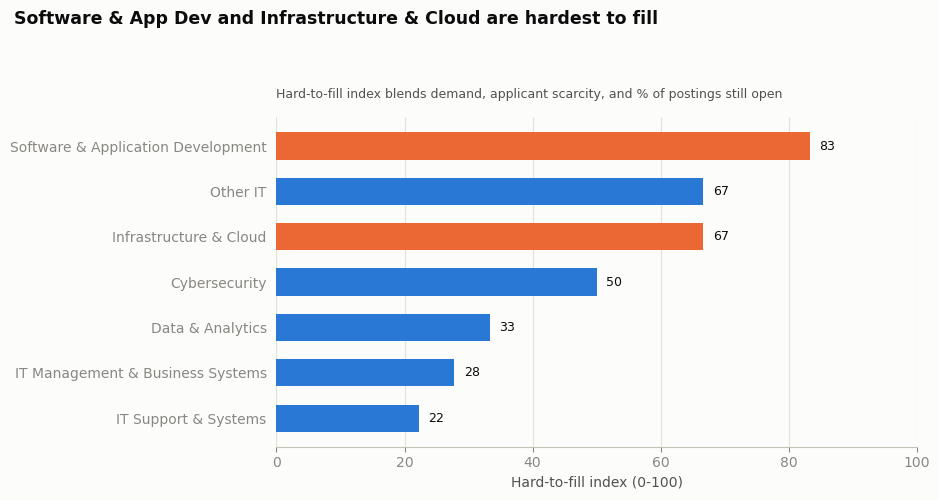

In [12]:
d = category_metrics.sort_values('hard_to_fill_index')
colors = [ORANGE if x in PRIORITY_CATS else BLUE for x in d['it_job_category']]

fig, ax = plt.subplots(figsize=(9.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(d['it_job_category'], d['hard_to_fill_index'], color=colors, height=0.6, zorder=3)
ax.set_xlim(0, 100)
ax.set_xlabel('Hard-to-fill index (0-100)')
fig.suptitle('Software & App Dev and Infrastructure & Cloud are hardest to fill',
             x=0.02, y=0.99, ha='left', fontsize=12.5, fontweight='bold', color=TXT_PRIMARY)
ax.set_title('Hard-to-fill index blends demand, applicant scarcity, and % of postings still open',
             loc='left', fontsize=9, color=TXT_SECONDARY, pad=14)
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(AXIS)
ax.tick_params(left=False)
for bar, val in zip(bars, d['hard_to_fill_index']):
    ax.text(val + 1.5, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', fontsize=9, color=TXT_PRIMARY)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('chart_hard_to_fill_index.png', dpi=150, facecolor=SURFACE)
plt.show()

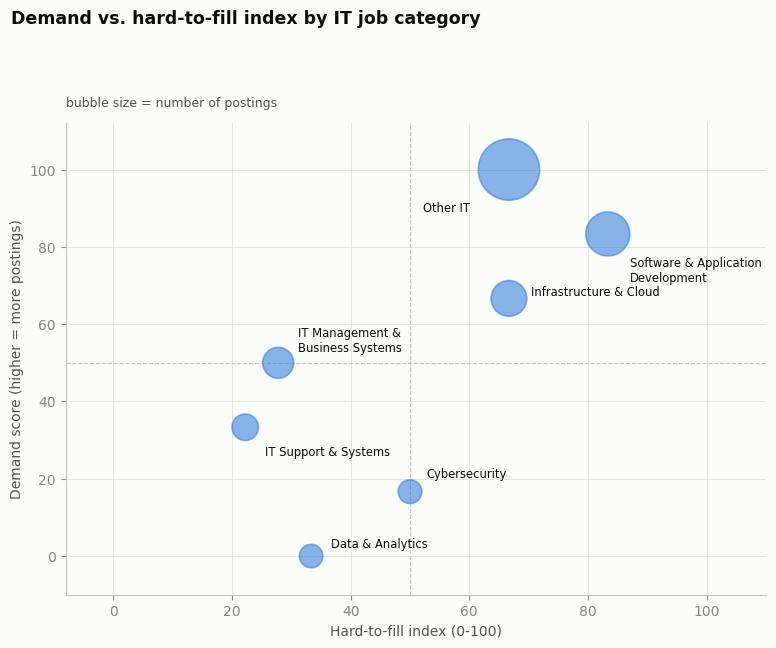

In [13]:
fig, ax = plt.subplots(figsize=(8, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
sizes = category_metrics['job_postings'] / category_metrics['job_postings'].max() * 1800 + 150
ax.scatter(category_metrics['hard_to_fill_index'], category_metrics['demand_score'],
           s=sizes, color=BLUE, alpha=0.55, edgecolor=BLUE, linewidth=1.2, zorder=3)
ax.axhline(50, color=AXIS, linewidth=0.8, linestyle='--', zorder=1)
ax.axvline(50, color=AXIS, linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlim(-8, 110)
ax.set_ylim(-10, 112)
ax.set_xlabel('Hard-to-fill index (0-100)')
ax.set_ylabel('Demand score (higher = more postings)')
fig.suptitle('Demand vs. hard-to-fill index by IT job category', x=0.02, y=0.99, ha='left',
             fontsize=12.5, fontweight='bold', color=TXT_PRIMARY)
ax.set_title('bubble size = number of postings', loc='left', fontsize=9, color=TXT_SECONDARY, pad=12)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(AXIS)
ax.spines['bottom'].set_color(AXIS)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

offsets = {
    'Software & Application Development': (16, -34),
    'Infrastructure & Cloud': (16, 2),
    'Other IT': (-28, -30),
    'Cybersecurity': (12, 10),
    'Data & Analytics': (14, 6),
    'IT Management & Business Systems': (14, 8),
    'IT Support & Systems': (14, -20),
}
for _, row in category_metrics.iterrows():
    dx, dy = offsets.get(row['it_job_category'], (10, 10))
    ha = 'left' if dx >= 0 else 'right'
    ax.annotate(wrap(row['it_job_category'], 22), (row['hard_to_fill_index'], row['demand_score']),
                textcoords='offset points', xytext=(dx, dy), fontsize=8.3, color=TXT_PRIMARY,
                linespacing=1.2, ha=ha)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('chart_demand_vs_scarcity.png', dpi=150, facecolor=SURFACE)
plt.show()

Same 7 categories plotted directly on their two raw component scores (scarcity score on the x-axis, demand score on the y-axis) rather than against the blended `hard_to_fill_index`. The dashed lines mark the median (50) on each axis, so the top-right quadrant is where both hiring pressure signals agree: high posting volume **and** a thin applicant pool. Software & Application Development and Infrastructure & Cloud both sit there; Other IT has the most postings but a healthier applicant pool, confirming it's a volume story rather than a scarcity one.

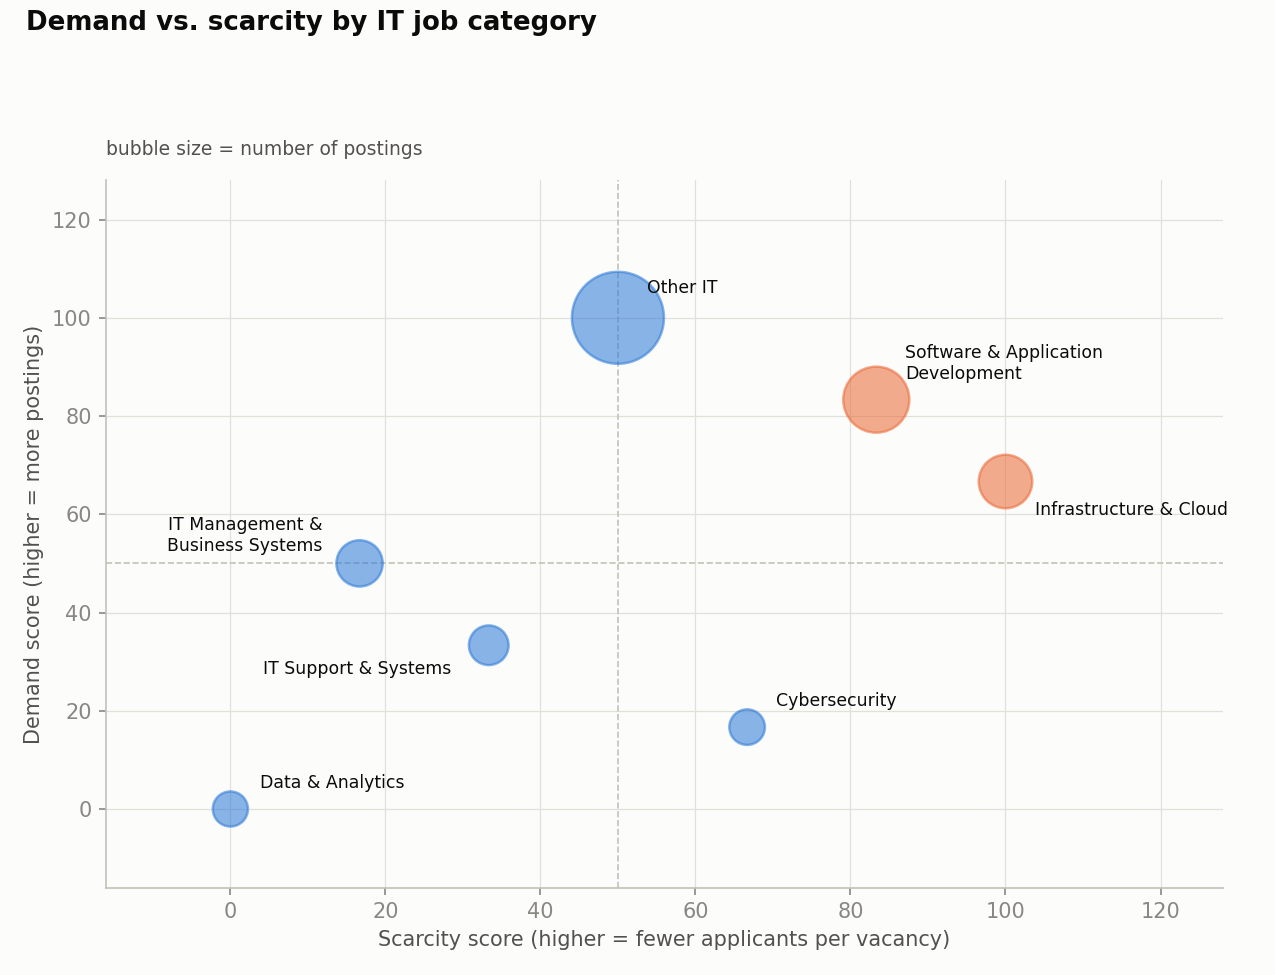

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
sizes = category_metrics['job_postings'] / category_metrics['job_postings'].max() * 1800 + 150
colors = [ORANGE if x in PRIORITY_CATS else BLUE for x in category_metrics['it_job_category']]
ax.scatter(category_metrics['scarcity_score'], category_metrics['demand_score'],
           s=sizes, color=colors, alpha=0.55, edgecolor=colors, linewidth=1.2, zorder=3)
ax.axhline(50, color=AXIS, linewidth=0.8, linestyle='--', zorder=1)
ax.axvline(50, color=AXIS, linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlim(-16, 128)
ax.set_ylim(-16, 128)
ax.set_xlabel('Scarcity score (higher = fewer applicants per vacancy)')
ax.set_ylabel('Demand score (higher = more postings)')
fig.suptitle('Demand vs. scarcity by IT job category', x=0.02, y=0.99, ha='left',
             fontsize=12.5, fontweight='bold', color=TXT_PRIMARY)
ax.set_title('bubble size = number of postings', loc='left', fontsize=9, color=TXT_SECONDARY, pad=12)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(AXIS)
ax.spines['bottom'].set_color(AXIS)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

offsets = {
    'Software & Application Development': (14, 10),
    'Infrastructure & Cloud': (14, -16),
    'Other IT': (14, 12),
    'Cybersecurity': (14, 10),
    'Data & Analytics': (14, 10),
    'IT Management & Business Systems': (-18, 6),
    'IT Support & Systems': (-18, -14),
}
for _, row in category_metrics.iterrows():
    dx, dy = offsets.get(row['it_job_category'], (10, 10))
    ha = 'left' if dx >= 0 else 'right'
    ax.annotate(wrap(row['it_job_category'], 22), (row['scarcity_score'], row['demand_score']),
                textcoords='offset points', xytext=(dx, dy), fontsize=8.3, color=TXT_PRIMARY,
                linespacing=1.2, ha=ha)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('chart_demand_vs_scarcity_score.png', dpi=150, facecolor=SURFACE)
plt.show()

Based on the above findings, here are the HR recommendations mapped to each category's specific problem:

1. Software & Application Development — top priority, sourcing/pipeline problem

Widest possible sourcing: expand beyond local applicant pools (0.70 applicants/vacancy is the tightest of any real specialism) — partner with universities/bootcamps, consider overseas/remote hires, employee referral bonuses.
Review compensation competitiveness against market rate — 86.7% of postings stay open, suggesting offers aren't converting.
Shorten time-to-hire (streamline interview loops) since roles sit open a long time; every extra week increases risk of losing candidates to competitors.
2. Infrastructure & Cloud — #2 priority, acute scarcity problem

This has the scarcest talent pool overall (0.60 applicants/vacancy) — treat as a build-vs-buy problem: invest in upskilling/reskilling internal IT Support staff into cloud roles rather than relying solely on external hiring.
Consider certifications-sponsorship programs (AWS/Azure/GCP) to grow the internal pipeline.
Explore contractor/managed-service partnerships to bridge gaps while internal capability is built.
3. Data & Analytics — skills/qualification mismatch, not a sourcing problem

Applicant supply is healthy (2.44/vacancy) but 87.9% of postings stay open — the issue is candidates aren't meeting the bar, not too few candidates. Recommend:
Re-examine job requirements — are they overspecified or misaligned with what the role actually needs?
Add technical assessments/case studies earlier in the pipeline to filter faster and reduce wasted interview cycles.
Invest in structured training/onboarding to hire for potential and develop skills in-house rather than requiring exact-match experience.
4. "Other IT" — fix the data before acting on it

Don't treat this as a single hiring priority — it's a labeling artifact, not a real specialism. Recommend working with the data/HRIS team to re-tag postings into proper specialisms so future hard-to-fill analysis is actionable (a catch-all bucket can't get a targeted intervention).
5. IT Support & Systems — deprioritize

Lowest hard-to-fill index and fastest close-out; no urgent action needed. Keep sourcing channels as-is.
Cross-cutting recommendation

Reposting rate is low (94% never reposted) — this signals roles are being left open rather than re-advertised when unfilled, which may itself mask true scarcity. Recommend auditing whether "Open" status roles are actively being worked (sourcing/interviewing) or effectively stalled/deprioritized, since that distinction changes the urgency of the fixes above.
Want me to add this as a markdown section directly in the notebook, or keep it as a standalone summary for the report?

